## 🎯 Simulating the FIFA World Cup with the Monte Carlo Method

Now that our Poisson Regression model can estimate the **expected goals (xG)** for every match, the next step is to simulate an entire FIFA World Cup tournament.

The challenge is that expected goals are **average values**, not actual match scores. For example, a prediction of **1.16 expected goals** does not mean a team will score exactly 1.16 goals, since football matches can only end with whole numbers such as **0, 1, 2, or 3 goals**.

To generate realistic match results, we use the **Poisson distribution** through the NumPy function:

```python
np.random.poisson(xG)
```

This function treats the expected goals as the average scoring rate and randomly generates an integer number of goals for each team.

For example, if **France** has an expected goal value of **1.16**, repeated simulations might produce results such as:

| Simulation | Goals Scored |
|------------|-------------:|
| 1 | 1 |
| 2 | 2 |
| 3 | 1 |
| 4 | 0 |
| 5 | 1 |
| 6 | 2 |
| 7 | 4 *(rare)* |

Most of the time, the generated score will be close to the expected value. Occasionally, the simulation produces unusually high or low scores, reflecting the natural uncertainty and unpredictability of football.

This randomness is one of the greatest strengths of the Monte Carlo approach, as it allows the model to capture unexpected results and famous upsets that occur in real tournaments.

### ⚽ Simulating a Knockout Match

Each knockout match is simulated using the following process:

1. Use the Poisson Regression model to estimate the expected goals for both teams.
2. Generate whole-number goals for each team using `np.random.poisson()`.
3. Compare the simulated scores to determine the winner.
4. If the match ends in a draw, simulate a **50–50 penalty shootout** to decide which team advances.
5. Repeat the process for every match until a tournament champion is crowned.

### 🔁 Repeating the Tournament Thousands of Times

A single simulated tournament represents only one possible outcome.

To estimate each team's true chances of winning the FIFA World Cup, we repeat the **entire knockout tournament thousands of times** (e.g., **10,000 simulations**).

Each simulation introduces slight variations in match results due to the randomness of the Poisson distribution. After all simulations are complete, we count how many times each team won the tournament.

For example:

| Team | Tournament Wins | Winning Probability |
|------|----------------:|--------------------:|
| Brazil | 2,870 | 28.7% |
| France | 2,130 | 21.3% |
| Argentina | 1,620 | 16.2% |
| England | 980 | 9.8% |

These probabilities provide a much richer prediction than simply selecting one team as the winner. Instead, they quantify the likelihood of each team becoming world champion while accounting for both team strength and the inherent randomness of football.

> **Key Takeaway:**  
> The Monte Carlo Simulation transforms expected goals into realistic football matches by using the Poisson distribution to generate whole-number scores. By repeating the entire tournament thousands of times, the model captures both the statistical strength of each team and the unpredictability that makes football so exciting.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from tqdm import tqdm # This creates our loading bar!

Matplotlib is building the font cache; this may take a moment.


In [2]:
# 1. SETUP & RE-TRAIN THE MODEL (Takes 1 second)

df = pd.read_csv('../data/final/master_training_data.csv')
df['home_ea_score'] = df['home_ea_score'].fillna(60)
df['away_ea_score'] = df['away_ea_score'].fillna(60)
df['home_tm_value'] = df['home_tm_value'].fillna(1000000)
df['away_tm_value'] = df['away_tm_value'].fillna(1000000)
df['home_fifa_rank'] = df['home_fifa_rank'].fillna(150)
df['away_fifa_rank'] = df['away_fifa_rank'].fillna(150)

home_data = pd.DataFrame({'team': df['home_team'], 'opponent': df['away_team'], 'goals': df['home_score'], 'is_home_advantage': np.where(df['neutral'] == True, 0, 1), 'rank_diff': df['away_fifa_rank'] - df['home_fifa_rank'], 'ea_diff': df['home_ea_score'] - df['away_ea_score'], 'tm_log_diff': np.log1p(df['home_tm_value']) - np.log1p(df['away_tm_value'])})
away_data = pd.DataFrame({'team': df['away_team'], 'opponent': df['home_team'], 'goals': df['away_score'], 'is_home_advantage': 0, 'rank_diff': df['home_fifa_rank'] - df['away_fifa_rank'], 'ea_diff': df['away_ea_score'] - df['home_ea_score'], 'tm_log_diff': np.log1p(df['away_tm_value']) - np.log1p(df['home_tm_value'])})
goal_data = pd.concat([home_data, away_data], ignore_index=True).dropna(subset=['goals'])

poisson_model = smf.glm(formula="goals ~ is_home_advantage + rank_diff + ea_diff + tm_log_diff", data=goal_data, family=sm.families.Poisson()).fit()

# Load Latest Stats
df_ea = pd.read_csv('../data/processed/ea_squad_strength.csv')
df_tm = pd.read_csv('../data/processed/tm_squad_value.csv')
df_fifa = pd.read_csv('../data/processed/fifa_rankings.csv')

latest_ea = df_ea[df_ea['year'] == 2024].set_index('country')['ea_squad_score'].to_dict()
latest_tm = df_tm.sort_values('year').groupby('country').tail(1).set_index('country')['tm_squad_value_eur'].to_dict()
latest_fifa = df_fifa.sort_values('rank_date').groupby('country').tail(1).set_index('country')['fifa_rank'].to_dict()


In [3]:
# 2. THE MATCH SIMULATOR
# ---------------------------------------------------------
def simulate_match(team1, team2):
    t1_rank, t2_rank = latest_fifa.get(team1, 150), latest_fifa.get(team2, 150)
    t1_ea, t2_ea = latest_ea.get(team1, 60), latest_ea.get(team2, 60)
    t1_tm, t2_tm = latest_tm.get(team1, 1000000), latest_tm.get(team2, 1000000)
    
    # We assume neutral venue for the bracket (unless USA plays)
    t1_adv = 1 if team1 in ['United States', 'Mexico', 'Canada'] else 0
    t2_adv = 1 if team2 in ['United States', 'Mexico', 'Canada'] else 0

    t1_input = pd.DataFrame({'is_home_advantage': [t1_adv], 'rank_diff': [t2_rank - t1_rank], 'ea_diff': [t1_ea - t2_ea], 'tm_log_diff': [np.log1p(t1_tm) - np.log1p(t2_tm)]})
    t2_input = pd.DataFrame({'is_home_advantage': [t2_adv], 'rank_diff': [t1_rank - t2_rank], 'ea_diff': [t2_ea - t1_ea], 'tm_log_diff': [np.log1p(t2_tm) - np.log1p(t1_tm)]})
    
    t1_xG = poisson_model.predict(t1_input).values[0]
    t2_xG = poisson_model.predict(t2_input).values[0]
    
    # MAGIC HAPPENS HERE: Roll the Poisson dice!
    t1_goals = np.random.poisson(t1_xG)
    t2_goals = np.random.poisson(t2_xG)
    
    if t1_goals > t2_goals: return team1
    elif t2_goals > t1_goals: return team2
    else:
        # PENALTY SHOOTOUT: 50/50 coin flip
        return team1 if np.random.rand() > 0.5 else team2

In [4]:
# 3. THE TOURNAMENT BRACKET
# ---------------------------------------------------------
def play_tournament(teams):
    current_round = teams
    while len(current_round) > 1:
        next_round = []
        for i in range(0, len(current_round), 2):
            winner = simulate_match(current_round[i], current_round[i+1])
            next_round.append(winner)
        current_round = next_round
    return current_round[0] # Returns the Champion

# Let's take the Top 32 Ranked Teams in the world for our bracket
top_32_teams = df_fifa.sort_values('rank_date').groupby('country').tail(1).sort_values('fifa_rank').head(32)['country'].tolist()


In [5]:
# 4. RUN THE MONTE CARLO SIMULATION (10,000 TIMES!)
# ---------------------------------------------------------
num_simulations = 10000
champions = []

print(f"Simulating the 2026 World Cup {num_simulations} times... Grab a coffee! ☕")
for _ in tqdm(range(num_simulations)):
    # Shuffle the bracket randomly each time so different teams play each other
    np.random.shuffle(top_32_teams) 
    champ = play_tournament(top_32_teams)
    champions.append(champ)

Simulating the 2026 World Cup 10000 times... Grab a coffee! ☕


100%|██████████| 10000/10000 [57:24<00:00,  2.90it/s] 


Chart saved successfully to the outputs folder!


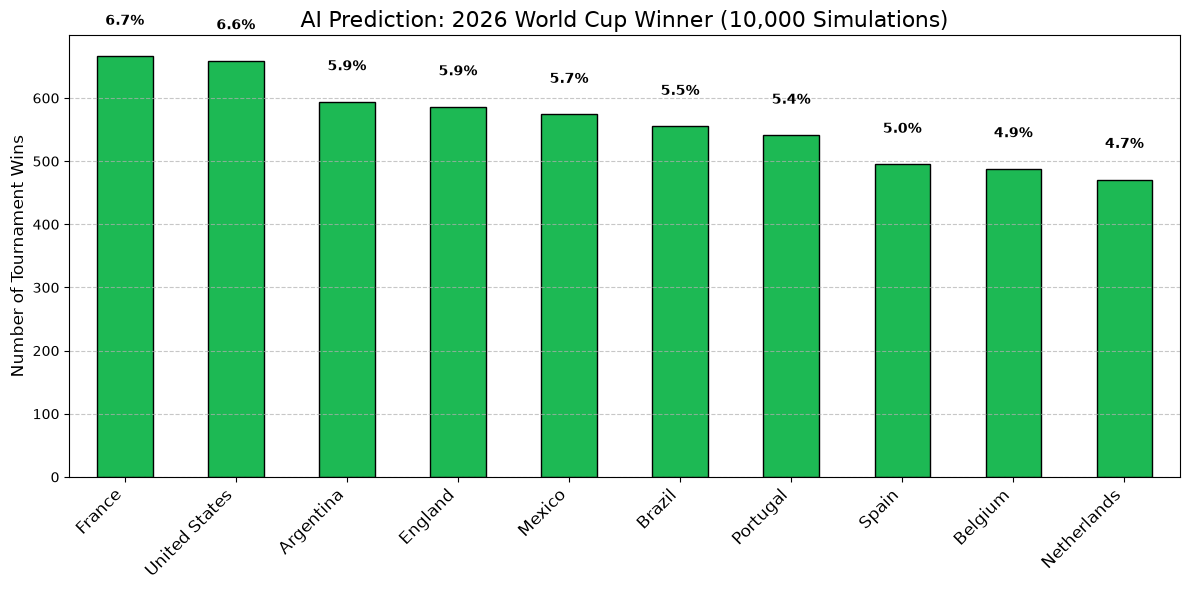

In [7]:
# 5. VISUALIZE THE PREDICTION!
# ---------------------------------------------------------
champ_counts = pd.Series(champions).value_counts().head(10) # Top 10 most likely winners

plt.figure(figsize=(12, 6))
champ_counts.plot(kind='bar', color='#1DB954', edgecolor='black')
plt.title('AI Prediction: 2026 World Cup Winner (10,000 Simulations)', fontsize=16)
plt.ylabel('Number of Tournament Wins', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact percentage labels on top of the bars
for i, v in enumerate(champ_counts):
    plt.text(i, v + 50, f"{(v/num_simulations)*100:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/2026_world_cup_prediction.png', dpi=300, bbox_inches='tight')
print("Chart saved successfully to the outputs folder!")
plt.show()